# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example: notebooks/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/data/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths data/hw/hw_3/data/student-name/data.csv
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [41]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
#If you read csv/parquet etc use relative paths data/hw/hw_3/data/student-name/data.csv

#make function to get the path of the current repository. Build other paths based on this.
def get_repo_root() -> Path:
    current_path = Path.cwd().resolve()
    for parent in list(current_path.parents):
        if (parent / ".git").exists():
            return parent
    raise FileNotFoundError("Could not find repository root (no .git folder found).")

REPO_ROOT = get_repo_root()
HW3_ROOT = REPO_ROOT / 'notebooks' / 'hw' / 'hw_3'
HW3_DATA_ROOT = HW3_ROOT / 'hw_3_data_Joe_Carver'

print(f'repository root is: {REPO_ROOT}')
print(f'hw3 file root is: {HW3_ROOT}')
print(f'hw3 data root is: {HW3_DATA_ROOT}')

# 2. Acquire and load your primary dataset

# ---------------------------------------------------------------------------------
# OVERALL PROCESS AND GOAL
# - manually downloaded two datasets of interest and put them in hw3 folder
# - datasets are exchange rate data from 2012-2025 for select countries and 
#   visitors to Japan from select countries over the same time frame
# - goal is to observe correlation between currency exchange rate fluctuations 
#   and visitations to Japan. Tourism is an interesting policy area as it is important
#   economically but can be a political flashpoint.
# ---------------------------------------------------------------------------------

# ---------------------------------------------------------------------------------
# LOAD THE EXCHANGE RATE DATA 
# monthly data, manually selected for countries with high visitation to Japan in 2026)
# downloaded from https://data.imf.org/en/Data-Explorer
# note: this data is already relatively clean and usable
# ---------------------------------------------------------------------------------
exch_rate = pd.read_csv(HW3_DATA_ROOT / 'exchange_rate_data_2.csv')

# ---------------------------------------------------------------------------------
# LOAD THE VISITOR DATA 
# this data has monthly visitors from select countries to Japan
# data downloaded from: https://www.jnto.go.jp/statistics/data/visitors-statistics/
# original download link name: 国籍/月別 訪日外客数（2003年～2026年）（Excel）
# note: this data is a traditional Japanese government style PDF and is a mess, 
# with different years split over different sheets and many other such shenanigans 
# ---------------------------------------------------------------------------------

visitor_sheets = pd.read_excel(HW3_DATA_ROOT / 'visitors_to_japan_data.xlsx', skiprows=3, sheet_name=None)


repository root is: /Users/jocarver/Documents/GitHub/datascience-publicpolicy-2026
hw3 file root is: /Users/jocarver/Documents/GitHub/datascience-publicpolicy-2026/notebooks/hw/hw_3
hw3 data root is: /Users/jocarver/Documents/GitHub/datascience-publicpolicy-2026/notebooks/hw/hw_3/hw_3_data_Joe_Carver


### **Dataset Context & Relevance**

- **Dataset Source**
  - exchange rates: https://data.imf.org/en/Data-Explorer
  - visitor data: https://www.jnto.go.jp/statistics/data/visitors-statistics/

  (additional explanation above)

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [42]:
# 1. Inspect EXCHANGE RATE data structure using pandas methods

#inspect current dataframe 
exch_rate.head()

,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDICATOR,TYPE_OF_TRANSFORMATION,FREQUENCY,SCALE,2012-M01,2012-M02,...,2025-M03,2025-M04,2025-M05,2025-M06,2025-M07,2025-M08,2025-M09,2025-M10,2025-M11,2025-M12
0,IMF.STA:ER(4.0.1),TWN.XDC_USD.EOP_RT.M,OBS_VALUE,Taiwan Province of China,Domestic currency per US Dollar,End-of-period (EoP),Monthly,Units,29.6200,29.4200,...,33.1820,32.0170,29.9290,29.9020,29.9160,30.6050,30.4690,30.7490,31.4080,31.4380
1,IMF.STA:ER(4.0.1),VNM.XDC_USD.EOP_RT.M,OBS_VALUE,Vietnam,Domestic currency per US Dollar,End-of-period (EoP),Monthly,Units,20828.0000,20828.0000,...,24837.0000,24956.0000,24978.0000,25052.0000,25240.0000,25240.0000,25187.0000,25093.0000,25155.0000,25121.0000
2,IMF.STA:ER(4.0.1),PHL.XDC_USD.EOP_RT.M,OBS_VALUE,Philippines,Domestic currency per US Dollar,End-of-period (EoP),Monthly,Units,42.9460,42.8640,...,57.3820,56.2520,55.7030,56.5810,57.3060,57.0850,58.0420,59.0030,58.7920,58.8050
3,IMF.STA:ER(4.0.1),CAN.XDC_USD.EOP_RT.M,OBS_VALUE,Canada,Domestic currency per US Dollar,End-of-period (EoP),Monthly,Units,1.0028,0.9895,...,1.4376,1.3812,1.3758,1.3643,1.3844,1.3742,1.3921,1.4018,1.4059,1.3706
4,IMF.STA:ER(4.0.1),SGP.XDC_USD.EOP_RT.M,OBS_VALUE,Singapore,Domestic currency per US Dollar,End-of-period (EoP),Monthly,Units,1.2547,1.2474,...,1.3410,1.3077,1.2885,1.2758,1.2947,1.2835,1.2913,1.3001,1.2965,1.2841


In [43]:
# 2. Rename columns and select a clean subset
exch_rate.rename(columns = {'COUNTRY':'country'}, inplace = True)

#select only columns of with interest rates and add country as the index, cleaning country names
exch_rate_clean = exch_rate.iloc[:, 8:176]
exch_rate_clean.set_index(exch_rate['country'], inplace=True)
exch_rate_clean.rename(index = {'Taiwan Province of China':'Taiwan',
                                'Korea, Republic of':'South Korea',
                                'Euro Area (EA)': 'Euro Zone',
                                "Hong Kong Special Administrative Region, People's Republic of China":'Hong Kong',
                                "China, People's Republic of":'China'}, inplace=True)

#clean the column names and change to datetime
new_cols = []
for column in exch_rate_clean.columns:
    new_col = column.replace('M', '')
    new_col = pd.to_datetime(new_col, format = '%Y-%m')
    new_cols.append(new_col)

exch_rate_clean.columns = new_cols
exch_rate_clean.head()

#transpose index and columns to get datetime into index for plotting 
exch_rate_clean_t = exch_rate_clean.T
exch_rate_clean_t.index.name = 'date'

In [44]:
# 3. Filter row or column filters if necessary
# - currently all exchange rates are in terms of currency:dollar. 
# - change into terms of currency:yen by dividing currency/Dollar by yen/Dollar
# - for a given country, as the value of this metric goes up, the country's currency becomes
#   stronger against the yen

yen_exch_rate = exch_rate_clean_t.copy()
for column in yen_exch_rate.columns:
    #new_vals = yen_exch_rate[column] / exch_rate_clean_t['Japan']
    new_vals = exch_rate_clean_t['Japan'] / yen_exch_rate[column]
    yen_exch_rate[column] = new_vals

In [45]:
# 4. Handle missing values (NaNs) if necessary
# N/A for this dataset. Manually inspected and no missing values. 

### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [46]:
# 1. Load and clean the secondary dataset
# this dataset loaded above as a dictionary with several sheets for each year, 
# going back further than the exchange rate data
# years = [str(x) for x in range(2012,2026)]
visitor_sheets['2012'].head()

,Unnamed: 0,1月,伸率,2月,伸率.1,3月,伸率.2,4月,伸率.3,5月,...,9月,伸率.8,10月,伸率.9,11月,伸率.10,12月,伸率.11,累計,伸率.12
0,総数,681786.0,-4.525003,546451.0,-19.567761,676662.0,91.865055,779481.0,163.493067,667046.0,...,658239.0,22.184149,705848.0,14.641360,648548.0,17.581961,689679.0,20.551965,8358105.0,34.401645
1,アジア計,544694.0,-2.011423,420853.0,-22.039572,494079.0,95.735316,595389.0,170.391698,508260.0,...,497257.0,21.311191,503561.0,11.780728,485503.0,19.116994,516729.0,19.991222,6387977.0,35.233604
2,韓国,173000.0,-35.536279,169025.0,-27.031169,150291.0,68.637022,152323.0,138.788211,157141.0,...,145742.0,19.035251,168150.0,27.136906,183557.0,36.973636,199950.0,41.271479,2042775.0,23.201753
3,中国,136665.0,37.863030,81966.0,-22.205349,129302.0,107.048839,148793.0,95.358700,112152.0,...,121673.0,8.160508,69713.0,-34.340799,51993.0,-43.580311,52336.0,-34.323863,1425100.0,36.602489
4,台湾,125783.0,29.519642,85874.0,-8.103076,92057.0,118.688680,138735.0,287.527933,120992.0,...,118115.0,39.358865,135164.0,24.686586,123299.0,43.026668,111015.0,42.482192,1465753.0,47.463918


In [47]:
#define country mapping for translated Japanese names to English
country_mapping = {
    '韓国': 'South Korea',
    '中国': 'China',
    '台湾': 'Taiwan',
    '香港': 'Hong Kong',
    'タイ': 'Thailand',
    'シンガポール': 'Singapore',
    'マレーシア': 'Malaysia',
    'インドネシア': 'Indonesia',
    'フィリピン': 'Philippines',
    'ベトナム': 'Vietnam',
    'インド': 'India',
    'イスラエル': 'Israel',
    'トルコ': 'Turkey',
    'マカオ': 'Macau',
    'モンゴル': 'Mongolia',
    '英国': 'United Kingdom',
    'フランス': 'France',
    'ドイツ': 'Germany',
    'イタリア': 'Italy',
    'ロシア': 'Russia',
    'スペイン': 'Spain',
    'スウェーデン': 'Sweden',
    'オランダ': 'Netherlands',
    'スイス': 'Switzerland',
    'ベルギー': 'Belgium',
    'フィンランド': 'Finland',
    'ポーランド': 'Poland',
    'デンマーク': 'Denmark',
    'ノルウェー': 'Norway',
    'オーストリア': 'Austria',
    'ポルトガル': 'Portugal',
    'アイルランド': 'Ireland',
    '米国': 'United States',
    'カナダ': 'Canada',
    'メキシコ': 'Mexico',
    'ブラジル': 'Brazil',
    '豪州': 'Australia',
    'ニュージーランド': 'New Zealand'
}

In [48]:
# define a function for cleaning up one sheet 

def clean_sheet(year):
    year = year
    df = visitor_sheets[year]
    df = df.rename(columns = {'Unnamed: 0' : 'country'})
    df['country'] = df['country'].astype('string')
    if len(df.query('country.str.contains("地域")', engine='python')) > 0:
        df['country'] = df['country'].combine_first(df['Unnamed: 1'])
        df = df.drop(columns = ['Unnamed: 1'])

    df = df.filter(regex="country|月")
    conditions = ['not country.str.contains("計")', 
                  'country != "総数"',
                  'not country.str.contains("GCC6か国")',
                  'not country.str.contains("その他")',
                  'not country.str.contains("地域")',
                  'not country.str.contains("注")']

    df = df.query(" and ".join(conditions), engine='python')

    old_cols = df.columns[1:]
    new_cols = [pd.to_datetime(year + '-' + col.replace('月', ''), format = '%Y-%m') for col in old_cols]

    df = df.rename(columns = dict(zip(old_cols, new_cols)))
    df = df.set_index('country')
    df = df.T
    df.index.name = 'date'
    df.columns = [col.strip() for col in df.columns]
    df.columns = [country_mapping[col] for col in df.columns]

    return df

# use the above function and pd.concat to stack the years together into a single dataframe
# called visitors
visitors = clean_sheet('2012')
years = [str(x) for x in range(2013,2026)]
for year in years:
    df = clean_sheet(year)
    visitors = pd.concat([visitors, df])


In [49]:
# 2. Merge your datasets on a common key

# goal is to merge the exchange rate data and visitors data based on the columns (country)

merged = pd.concat([visitors, yen_exch_rate], axis = 1, keys=['visitors', 'exchange_rate'])

### **Merge Verification**

- **Merge Key**
  - merge happened on columns (countries)
- **Observations Retained**
  - all rows were retained since the time period indices matched exactly

In [50]:
#--------------------------------------------------------------------------------
# print column merge details - note: column was changed into multi-index so all 
# were retained
#--------------------------------------------------------------------------------

print(f'number of countries in exchange rate data: {len(yen_exch_rate.columns)}')
print(f'number of countries in visitors data: {len(visitors.columns)}')
print(f'number of countries in merged data [exchange rate]: {len(merged["exchange_rate"].columns)}')
print(f'number of countries in merged data [visitors]: {len(merged["visitors"].columns)}')

number of countries in exchange rate data: 17
number of countries in visitors data: 38
number of countries in merged data [exchange rate]: 17
number of countries in merged data [visitors]: 38


In [51]:
#--------------------------------------------------------------------------------
# print row merge details - rows matched exactly so all retained
#--------------------------------------------------------------------------------
print(f'number of rows in exchange rate data: {len(yen_exch_rate.index)}')
print(f'number of rows in visitors data: {len(visitors.index)}')
print(f'number of rows in merged data [exchange rate]: {len(merged["exchange_rate"].index)}')
print(f'number of rows in merged data [visitors]: {len(merged["visitors"].index)}')

number of rows in exchange rate data: 168
number of rows in visitors data: 168
number of rows in merged data [exchange rate]: 168
number of rows in merged data [visitors]: 168


### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [52]:
# Apply groupby aggregation or implement one of the backup grouping strategies

# create dictionary to map countries to their geographic region
country_to_region = {
    # --- North America ---
    'United States': 'North America',
    'Canada': 'North America',
    'Mexico': 'North America',

    # --- Asia ---
    'South Korea': 'Asia',
    'China': 'Asia',
    'Taiwan': 'Asia',
    'Hong Kong': 'Asia',
    'Thailand': 'Asia',
    'Singapore': 'Asia',
    'Malaysia': 'Asia',
    'Indonesia': 'Asia',
    'Philippines': 'Asia',
    'Vietnam': 'Asia',
    'India': 'Asia',
    'Israel': 'Asia',
    'Turkey': 'Asia',
    'Macau': 'Asia',
    'Mongolia': 'Asia',

    # --- Europe (euro) ---
    'France': 'Europe (euro)',
    'Germany': 'Europe (euro)',
    'Italy': 'Europe (euro)',
    'Spain': 'Europe (euro)',
    'Netherlands': 'Europe (euro)',
    'Belgium': 'Europe (euro)',
    'Finland': 'Europe (euro)',
    'Austria': 'Europe (euro)',
    'Portugal': 'Europe (euro)',
    'Ireland': 'Europe (euro)',

    # --- Europe (non-euro) ---
    'United Kingdom': 'Europe (non-euro)',
    'Russia': 'Europe (non-euro)',
    'Sweden': 'Europe (non-euro)',
    'Switzerland': 'Europe (non-euro)',
    'Poland': 'Europe (non-euro)',
    'Denmark': 'Europe (non-euro)',
    'Norway': 'Europe (non-euro)',

    # --- South America ---
    'Brazil': 'South America',

    # --- Oceania ---
    'Australia': 'Oceania',
    'New Zealand': 'Oceania'
}

In [53]:
# group the visitor data by region and sum to get total visitors from that region
region_visitors = merged['visitors'].groupby(country_to_region, axis=1).sum()

# because the number of visitors is very different by region, also normalize the visitor 
# data to better be able to visualize trends
# normalized to 2012 visitor number

norm_region_visitors = region_visitors / region_visitors.iloc[0]

# also group by year to make data less noisy to look at
yearly_region_visitors = region_visitors.groupby(region_visitors.index.year).sum()
norm_yearly_region_visitors = yearly_region_visitors / yearly_region_visitors.iloc[0]



- *Extra Credit: Write your economic or policy related interpretation here*

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

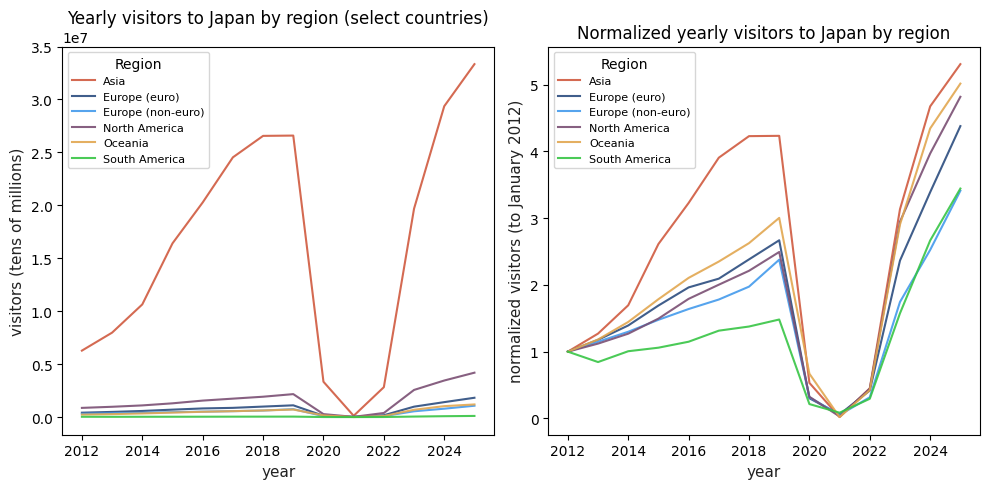

In [54]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups

# plot yearly visitors over time grouped by region

colors = ['#D05A3F','#2B4C7E', "#439AEC", '#7A4F73', '#E2A750', "#37C545"]
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (10,5))
ax1 = axes[0]
ax2 = axes[1]
for i, country in enumerate(yearly_region_visitors.columns):
    ax1.plot(yearly_region_visitors.index, yearly_region_visitors[country], 
            label = country,
            color = colors[i],
            alpha = 0.9
            )
ax1.set_title('Yearly visitors to Japan by region (select countries)')
ax1.set_xlabel('year', fontsize = 11, color = '#222222')
ax1.set_ylabel('visitors (tens of millions)', fontsize = 11, color = '#222222')
ax1.legend(title = 'Region', fontsize = 8, loc = 'upper left')

for i, country in enumerate(yearly_region_visitors.columns):
    ax2.plot(norm_yearly_region_visitors.index, norm_yearly_region_visitors[country], 
            label = country,
            color = colors[i],
            alpha = 0.9
            )
ax2.set_title('Normalized yearly visitors to Japan by region')
ax2.set_xlabel('year', fontsize = 11, color = '#222222')
ax2.set_ylabel('normalized visitors (to January 2012)', fontsize = 11, color = '#222222')
ax2.legend(title = 'Region', fontsize = 8, loc = 'upper left')

plt.tight_layout()
plt.show()


### plot interpretation 
* visitors from Asia dwarf visitors from other regions at all time points 
* over time, there is clear upward trend in visitors to Japan, and this trend seems to have accelerated post-Covid


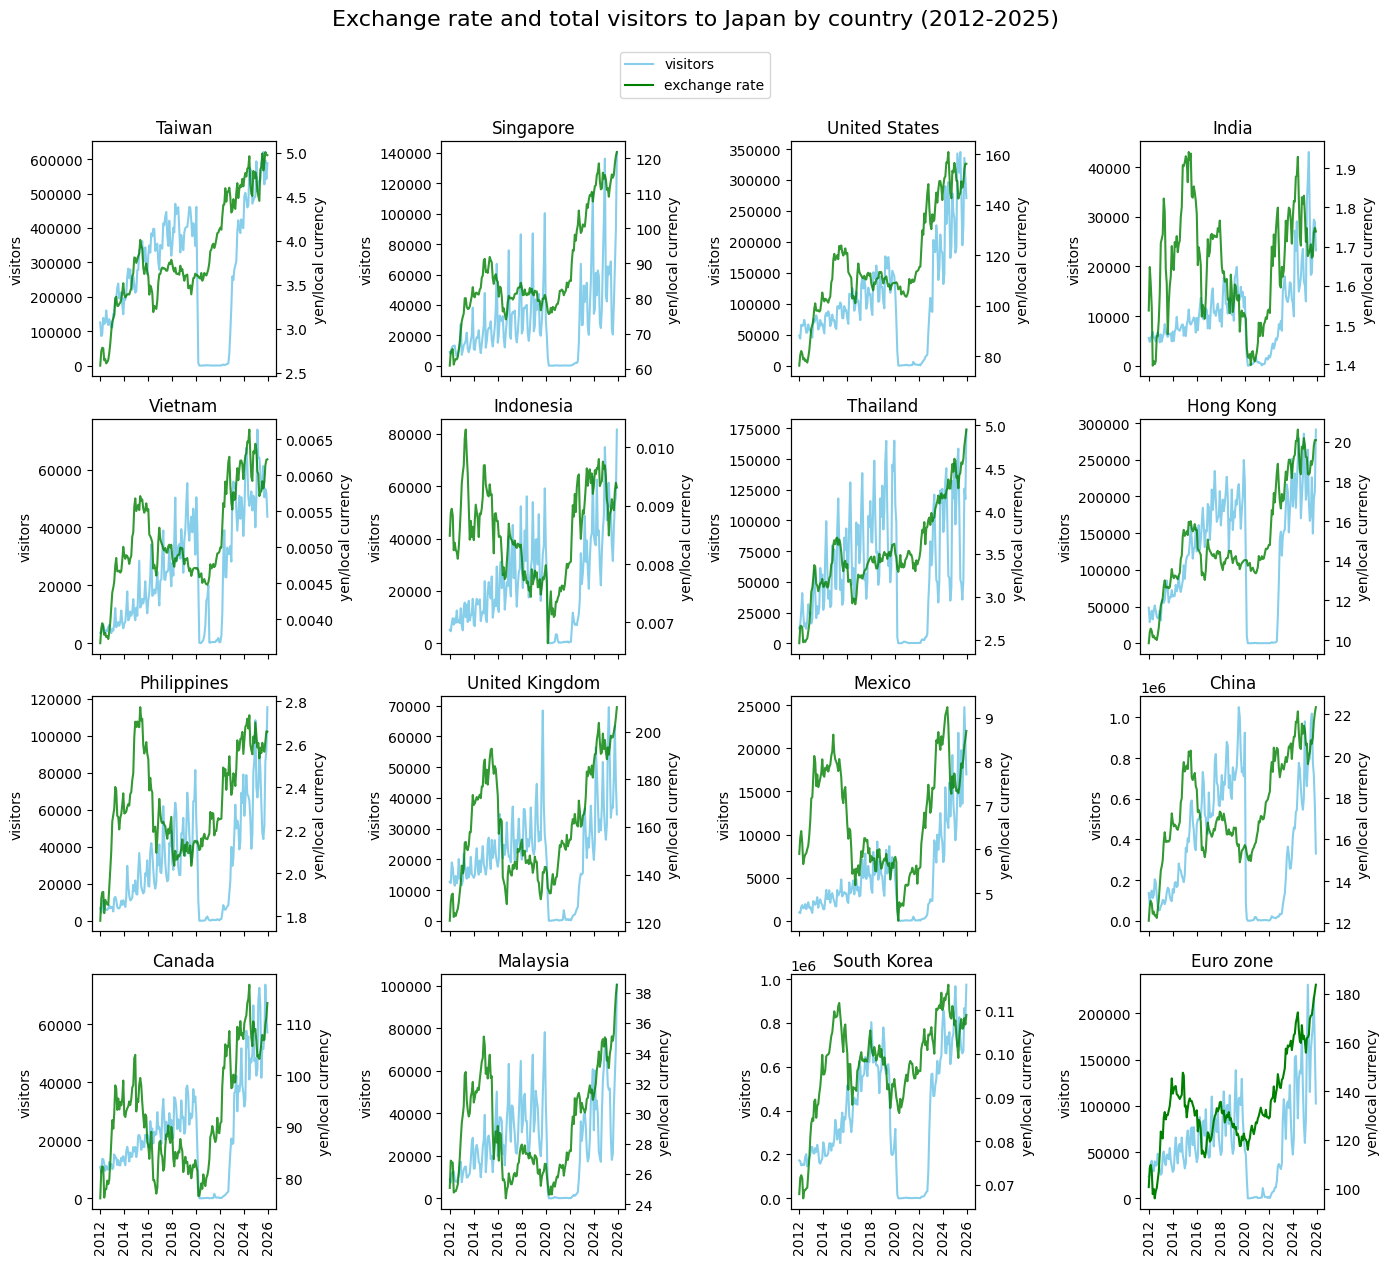

In [55]:
# Plot 2: Customized scatter plot of primary policy variables
# quick plot to visualize visitors vs exchange rate

countries = ['Taiwan', 'Vietnam', 'Philippines', 'Canada', 'Singapore', 'Indonesia',
        'United Kingdom', 'Malaysia', 'United States', 'Thailand',
       'Mexico', 'South Korea', 'India', 'Hong Kong', 'China']


fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(14, 12), sharex=True)
i = 0
j = 0
for country in countries:
    if i < 4:
        ax = axes[i,j]
        ax2 = ax.twinx() 
        try:
            ax.plot(merged["visitors"][country], color = 'skyblue')
            ax2.plot(merged['exchange_rate'][country], color = 'green', alpha = 0.8)
            ax.set_title(country)
            ax.set_ylabel('visitors')
            ax2.set_ylabel('yen/local currency')
            i += 1
        except KeyError:
            pass
    else:
        i = 0
        j += 1 
        ax = axes[i,j]
        ax2 = ax.twinx()
        try: 
            ax.plot(merged["visitors"][country], color = 'skyblue')
            ax2.plot(merged['exchange_rate'][country], color = 'green', alpha = 0.8)
            ax.set_title(country)
            ax.set_ylabel('visitors')
            ax2.set_ylabel('yen/local currency')
            i += 1
        except KeyError:
            pass

# for eurozone add the plot manually
euro_ax = axes[3,3]
euro_ax2 = euro_ax.twinx()
euro_ax.plot(region_visitors["Europe (euro)"], color = 'skyblue', label = 'visitors')
euro_ax2.plot(merged['exchange_rate']['Euro Zone'], color = 'green', label = 'exchange rate')
euro_ax.set_title('Euro zone')
euro_ax.set_ylabel('visitors')
euro_ax2.set_ylabel('yen/local currency')

for ax in axes.flat:
    ax.tick_params(axis='x', labelrotation = 90)

fig.legend(bbox_to_anchor=(0.5, 1.02), loc = 'upper center')
fig.suptitle('Exchange rate and total visitors to Japan by country (2012-2025)', y = 1.05, fontsize = 16)
fig.tight_layout()
plt.show()

### plot interpretation 
* since 2020 the yen has weakened against essentially every other currency, while visitations have increased substantially 
* before covid there are more varied patterns in exchange rates, although the trend of increased visitors to Japan holds true for every country

In [56]:
#set pre- and post- covid dates based on internet search of travel restrictions into Japan
covid_restriction_start = pd.to_datetime('2020-04', format = '%Y-%m')
covid_restriction_end = pd.to_datetime('2022-11', format = '%Y-%m')

#make new datasets for pre- and post-covid
pre_covid = merged.loc[:covid_restriction_start]
post_covid = merged.loc[covid_restriction_end:]

#for dealing with euro-zone date take grouping by region
pre_covid_europe = region_visitors.loc[:covid_restriction_start]
post_covid_europe = region_visitors.loc[covid_restriction_end:]

#stack them to exclude covid time period
exclude_covid = pd.concat([pre_covid, post_covid])
europe_exclude_covid = pd.concat([pre_covid_europe, post_covid_europe])

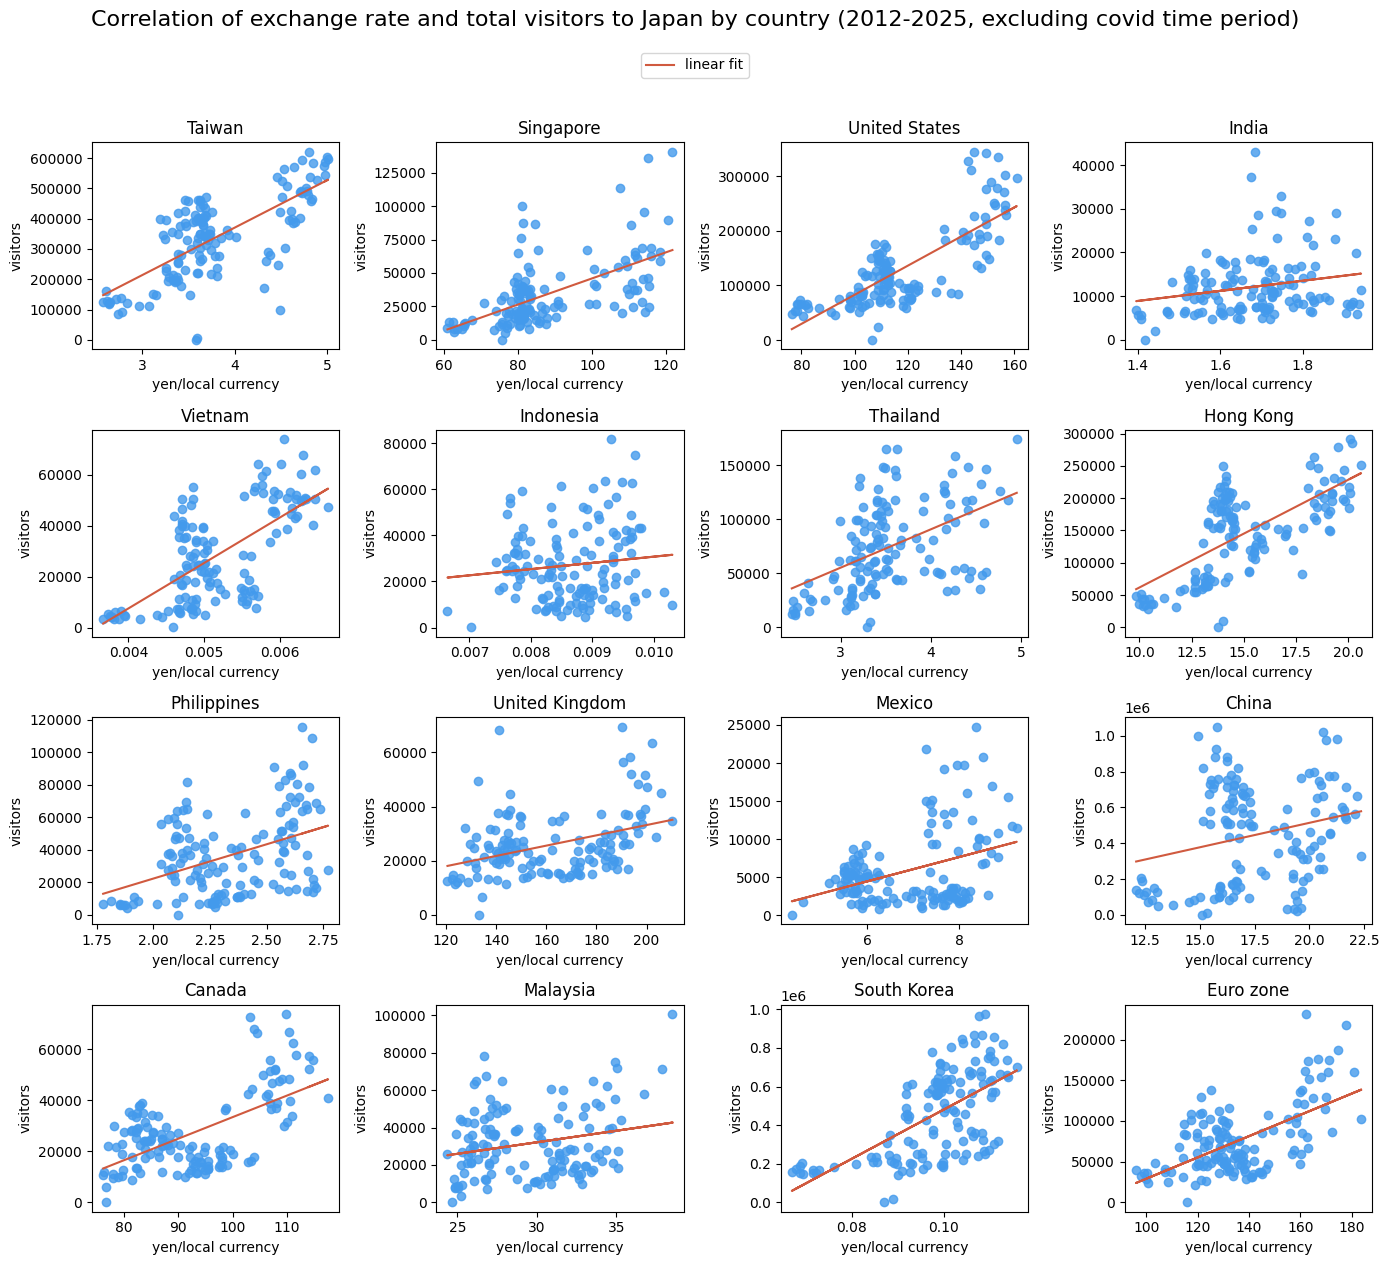

In [57]:
# Fit a simple linear regression and overlay the line of best fit
import statsmodels.api as sm

#define a helper function for calculating a regression fit
def calc_fit(country, x_df, y_df):
    X_real = x_df[country]
    Y_real = y_df[country]
    X_real_const = sm.add_constant(X_real)
    model_real = sm.OLS(Y_real, X_real_const).fit()
    return model_real

#plot correlations on data excluding covid time period
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(14, 12))
i = 0
j = 0
for country in countries:
    if i < 4:
        ax = axes[i,j]
        model_fit = calc_fit(country, exclude_covid['exchange_rate'], exclude_covid['visitors'])
        intercept, slope = model_fit.params.iloc[0], model_fit.params.iloc[1]
        ax.plot(exclude_covid['exchange_rate'][country], intercept + slope * exclude_covid['exchange_rate'][country], color ='#D05A3F')
        ax.scatter(exclude_covid['exchange_rate'][country], exclude_covid['visitors'][country], color = "#439AEC", alpha = 0.8)
        ax.set_title(country)
        ax.set_ylabel('visitors')
        ax.set_xlabel('yen/local currency')
        i += 1
    else:
        i = 0
        j += 1 
        ax = axes[i,j]
        model_fit = calc_fit(country, exclude_covid['exchange_rate'], exclude_covid['visitors'])
        intercept, slope = model_fit.params.iloc[0], model_fit.params.iloc[1]
        ax.plot(exclude_covid['exchange_rate'][country], intercept + slope * exclude_covid['exchange_rate'][country], color ='#D05A3F')
        ax.scatter(exclude_covid['exchange_rate'][country], exclude_covid['visitors'][country], color = "#439AEC", alpha = 0.8)
        ax.set_title(country)
        ax.set_ylabel('visitors')
        ax.set_xlabel('yen/local currency')
        i += 1

# for eurozone add the plot manually
euro_ax = axes[3,3]
X_europe = exclude_covid['exchange_rate']['Euro Zone']
Y_europe = europe_exclude_covid["Europe (euro)"]
X_europe_const = sm.add_constant(X_europe)
europe_model = sm.OLS(Y_europe, X_europe_const).fit()
intercept, slope = europe_model.params.iloc[0], europe_model.params.iloc[1]
euro_ax.plot(exclude_covid['exchange_rate']['Euro Zone'], intercept + slope * exclude_covid['exchange_rate']['Euro Zone'], color ='#D05A3F', label = 'linear fit')
euro_ax.scatter(exclude_covid['exchange_rate']['Euro Zone'], europe_exclude_covid['Europe (euro)'], color = "#439AEC", alpha = 0.8)
euro_ax.set_title('Euro zone')
euro_ax.set_ylabel('visitors')
euro_ax.set_xlabel('yen/local currency')

fig.legend(bbox_to_anchor=(0.5, 1.02), loc = 'upper center')
fig.suptitle('Correlation of exchange rate and total visitors to Japan by country (2012-2025, excluding covid time period)', y = 1.05, fontsize = 16)
fig.tight_layout()
plt.show()


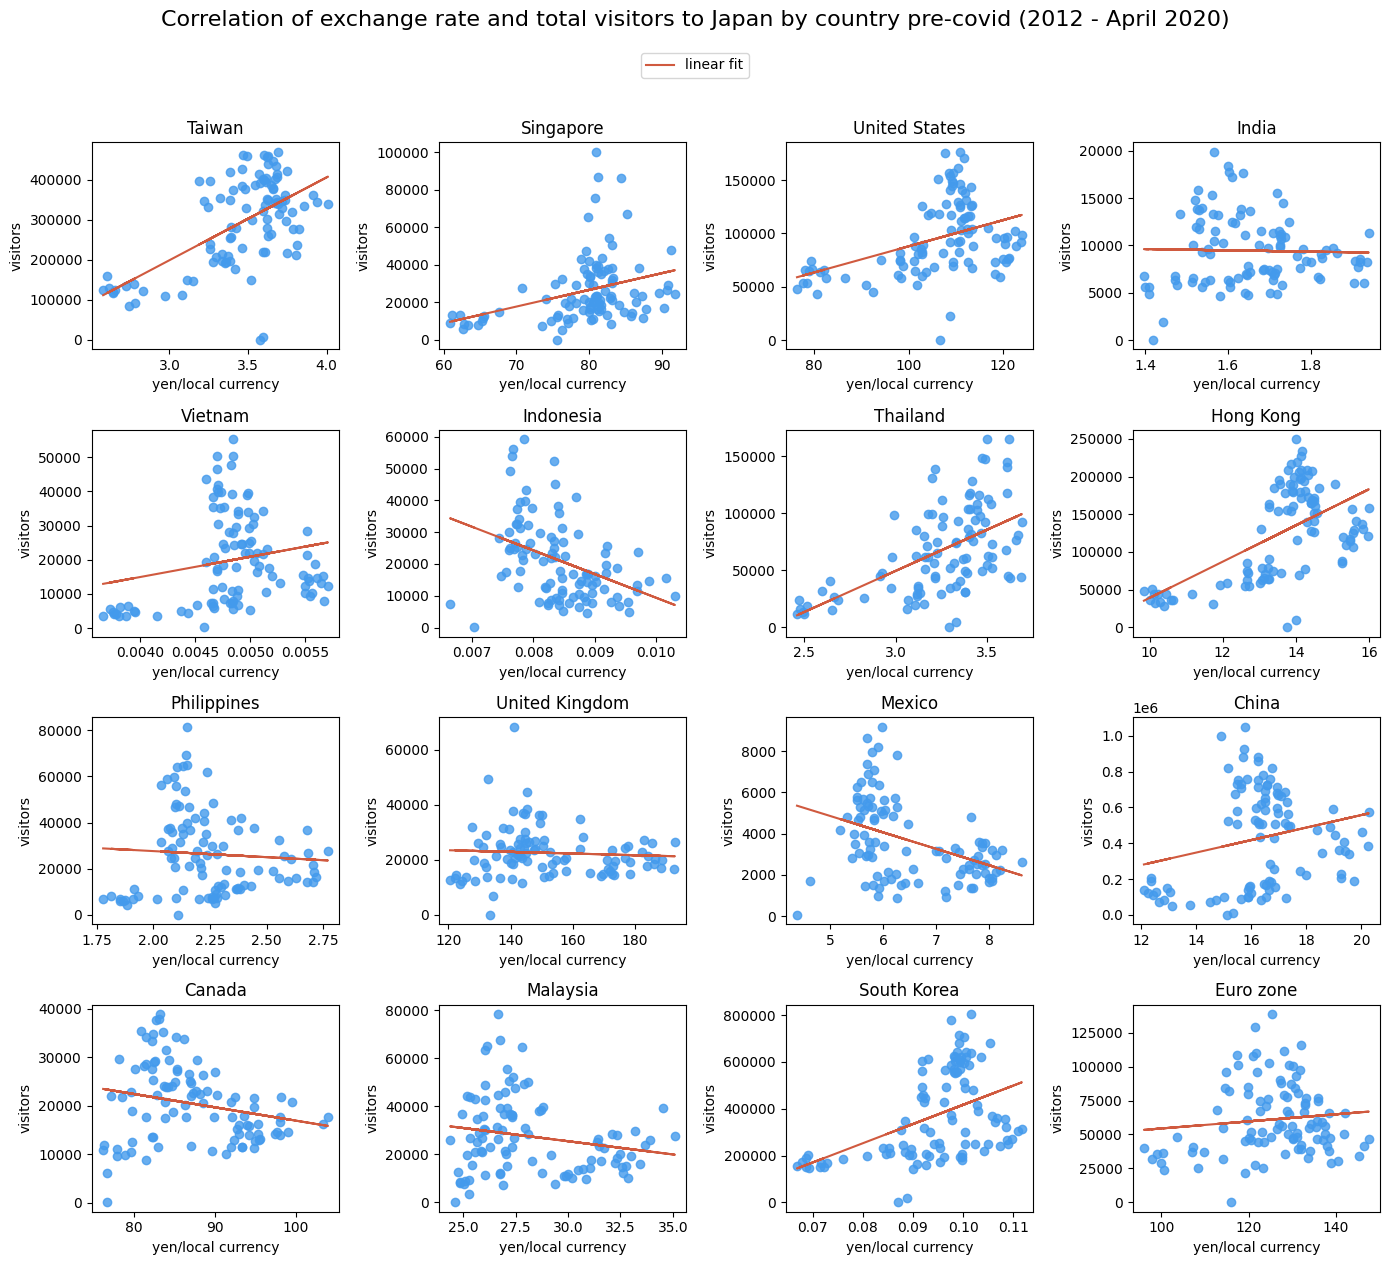

In [58]:

#plot correlations on pre-covid data
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(14, 12))
i = 0
j = 0
for country in countries:
    if i < 4:
        ax = axes[i,j]
        try:
            model_fit = calc_fit(country, pre_covid['exchange_rate'], pre_covid['visitors'])
            intercept, slope = model_fit.params.iloc[0], model_fit.params.iloc[1]
            ax.plot(pre_covid['exchange_rate'][country], intercept + slope * pre_covid['exchange_rate'][country], color ='#D05A3F')
            ax.scatter(pre_covid['exchange_rate'][country], pre_covid['visitors'][country], color = "#439AEC", alpha = 0.8)
            ax.set_title(country)
            ax.set_ylabel('visitors')
            ax.set_xlabel('yen/local currency')
            i += 1
        except KeyError:
            pass
    else:
        i = 0
        j += 1 
        ax = axes[i,j]
        try: 
            model_fit = calc_fit(country, pre_covid['exchange_rate'], pre_covid['visitors'])
            intercept, slope = model_fit.params.iloc[0], model_fit.params.iloc[1]
            ax.plot(pre_covid['exchange_rate'][country], intercept + slope * pre_covid['exchange_rate'][country], color ='#D05A3F')
            ax.scatter(pre_covid['exchange_rate'][country], pre_covid['visitors'][country], color = "#439AEC", alpha = 0.8)
            ax.set_title(country)
            ax.set_ylabel('visitors')
            ax.set_xlabel('yen/local currency')
            i += 1
        except KeyError:
            pass

# for eurozone add the plot manually
euro_ax = axes[3,3]
X_europe = pre_covid['exchange_rate']['Euro Zone']
Y_europe = pre_covid_europe["Europe (euro)"]
X_europe_const = sm.add_constant(X_europe)
europe_model = sm.OLS(Y_europe, X_europe_const).fit()
intercept, slope = europe_model.params.iloc[0], europe_model.params.iloc[1]
euro_ax.plot(pre_covid['exchange_rate']['Euro Zone'], intercept + slope * pre_covid['exchange_rate']['Euro Zone'], color ='#D05A3F', label = 'linear fit')
euro_ax.scatter(pre_covid['exchange_rate']['Euro Zone'], pre_covid_europe['Europe (euro)'], color = "#439AEC", alpha = 0.8)
euro_ax.set_title('Euro zone')
euro_ax.set_ylabel('visitors')
euro_ax.set_xlabel('yen/local currency')

fig.legend(bbox_to_anchor=(0.5, 1.02), loc = 'upper center')
fig.suptitle('Correlation of exchange rate and total visitors to Japan by country pre-covid (2012 - April 2020)', y = 1.05, fontsize = 16)
fig.tight_layout()
plt.show()


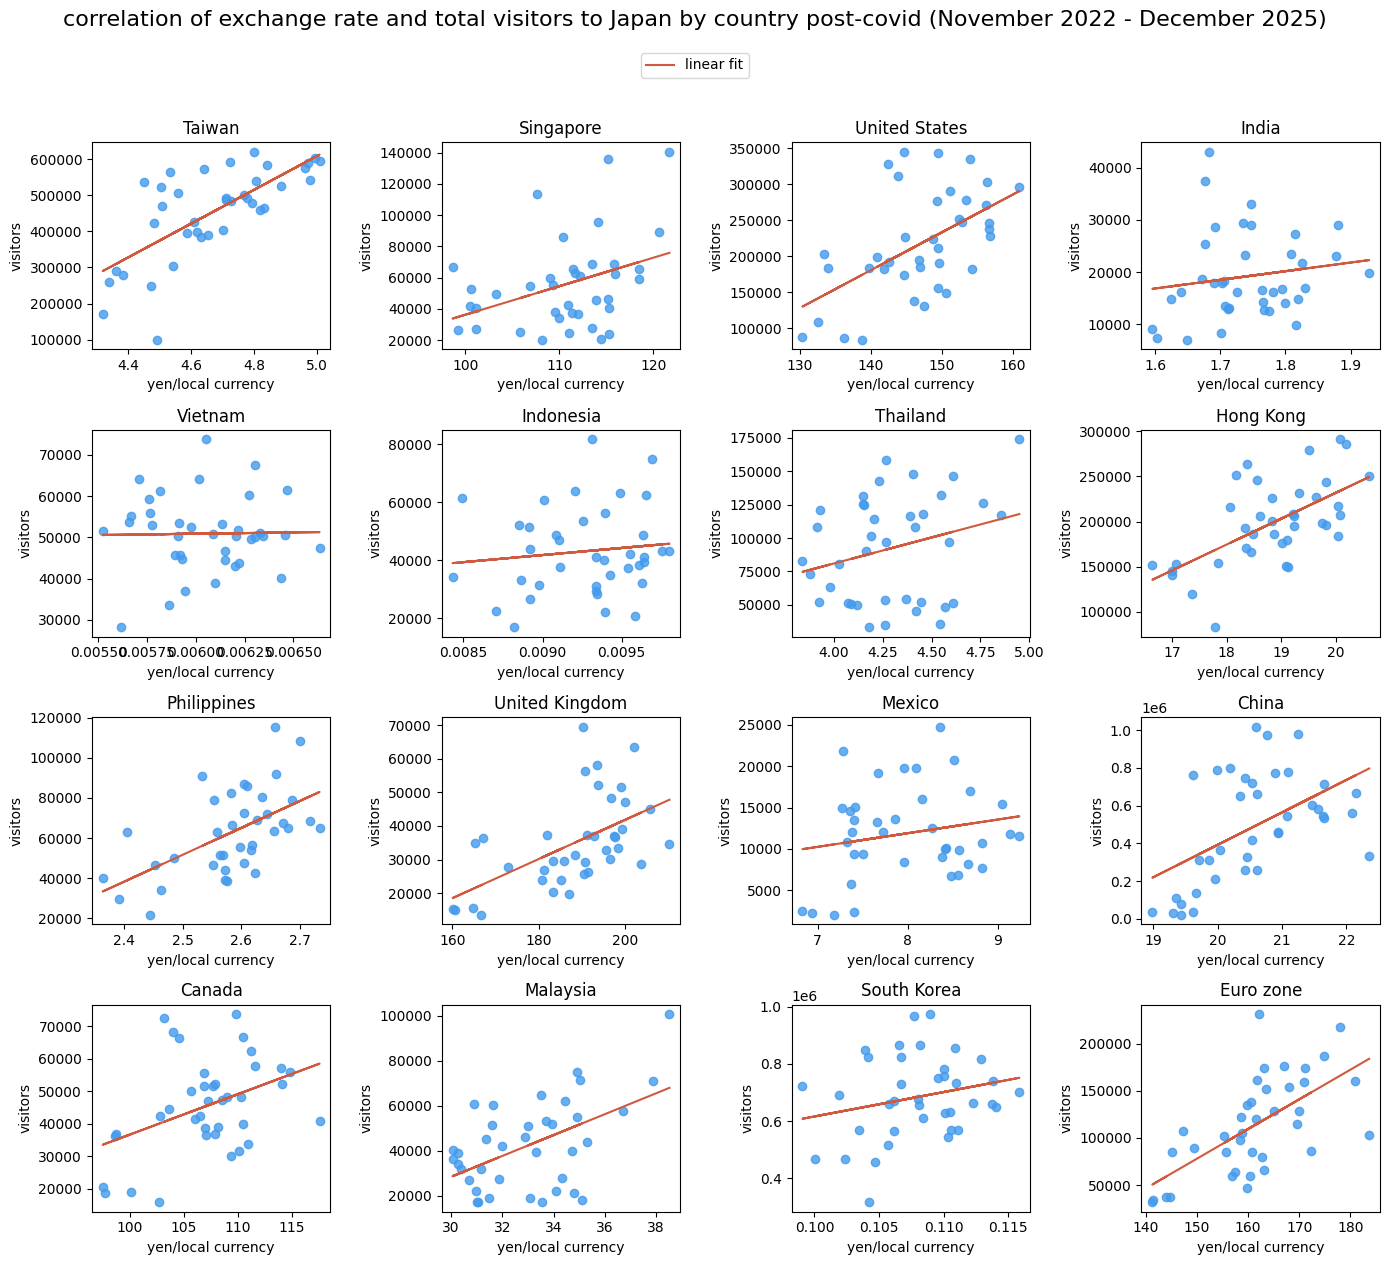

In [59]:

#plot correlations on post-covid data
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(14, 12))
i = 0
j = 0
for country in countries:
    if i < 4:
        ax = axes[i,j]
        try:
            model_fit = calc_fit(country, post_covid['exchange_rate'], post_covid['visitors'])
            intercept, slope = model_fit.params.iloc[0], model_fit.params.iloc[1]
            ax.plot(post_covid['exchange_rate'][country], intercept + slope * post_covid['exchange_rate'][country], color ='#D05A3F')
            ax.scatter(post_covid['exchange_rate'][country], post_covid['visitors'][country], color = "#439AEC", alpha = 0.8)
            ax.set_title(country)
            ax.set_ylabel('visitors')
            ax.set_xlabel('yen/local currency')
            i += 1
        except KeyError:
            pass
    else:
        i = 0
        j += 1 
        ax = axes[i,j]
        try: 
            model_fit = calc_fit(country, post_covid['exchange_rate'], post_covid['visitors'])
            intercept, slope = model_fit.params.iloc[0], model_fit.params.iloc[1]
            ax.plot(post_covid['exchange_rate'][country], intercept + slope * post_covid['exchange_rate'][country], color ='#D05A3F')
            ax.scatter(post_covid['exchange_rate'][country], post_covid['visitors'][country], color = "#439AEC", alpha = 0.8)
            ax.set_title(country)
            ax.set_ylabel('visitors')
            ax.set_xlabel('yen/local currency')
            i += 1
        except KeyError:
            pass

# for eurozone add the plot manually
euro_ax = axes[3,3]
X_europe = post_covid['exchange_rate']['Euro Zone']
Y_europe = post_covid_europe["Europe (euro)"]
X_europe_const = sm.add_constant(X_europe)
europe_model = sm.OLS(Y_europe, X_europe_const).fit()
intercept, slope = europe_model.params.iloc[0], europe_model.params.iloc[1]
euro_ax.plot(post_covid['exchange_rate']['Euro Zone'], intercept + slope * post_covid['exchange_rate']['Euro Zone'], color ='#D05A3F', label = 'linear fit')
euro_ax.scatter(post_covid['exchange_rate']['Euro Zone'], post_covid_europe['Europe (euro)'], color = "#439AEC", alpha = 0.8)
euro_ax.set_title('Euro zone')
euro_ax.set_ylabel('visitors')
euro_ax.set_xlabel('yen/local currency')

fig.legend(bbox_to_anchor=(0.5, 1.02), loc = 'upper center')
fig.suptitle('correlation of exchange rate and total visitors to Japan by country post-covid (November 2022 - December 2025)', y = 1.05, fontsize = 16)
fig.tight_layout()
plt.show()


## **overall interpretation**
* for certain countries it does appear that there may be a trend between a strengthening currency (relative to the yen) and visitation to Japan
* however, this occurs on the backdrop of increasing visitors to Japan over time for all countries
* understanding and managing an increase in tourism is an important political issue
* particularly post-covid, there is a substantial weakening of the yen and a substantial increase in visitors to Japan; these two trends may simply have happened to coincide. Therefore it is difficult to speculate on causality, although anecdotally some of the interest in travel to Japan is likely due to the weak yen. 
* for the visitor data there is strong seasonality, so in general it may be better to looked at moving average or some other smoothed representation if further analysis was conducted

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.